# NPSC2002 Workshop 7
## Global Space Agencies and the International Space Industry

This workshop builds an economic and political reading of space activity from 1957 to the present.

Each section poses a question where looking at the data changes what you would naively expect. Work through the sections in order -- each one sets up the next.

**The five questions:**
1. Has space participation become less concentrated, and what drove the expansion?
2. What structural shift made commercial space viable, and why didn't it happen sooner?
3. Does more commercial activity mean more science in space?
4. Who actually funds space infrastructure -- and who captures the returns?
5. What does an agency's mission mix reveal about national priorities?


---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Course palette
NAVY  = "#0B1F3A"
GOLD  = "#C9A84C"
WHITE = "#F0F4F8"
MUTED = "#7A9BB5"
LGOLD = "#E8D5A3"
RED   = "#C94C4C"
GREEN = "#5BA85A"
BLUE  = "#4A90D9"
ORANGE= "#E8845C"
PURPLE= "#C87CC9"
TEAL  = "#7EC8A4"

# Mission type colour map -- defined here so all sections can use it
TYPE_COLORS = {
    'Earth Observation':    TEAL,
    'Communications':       BLUE,
    'Navigation/GNSS':      PURPLE,
    'Science':              GOLD,
    'Military/Intelligence':RED,
    'Human Spaceflight':    LGOLD,
    'Technology Demo':      MUTED,
    'Other/Unknown':        "#445566",
}

plt.rcParams.update({
    'figure.facecolor':  NAVY,
    'axes.facecolor':    NAVY,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   WHITE,
    'axes.titlecolor':   GOLD,
    'xtick.color':       WHITE,
    'ytick.color':       WHITE,
    'text.color':        WHITE,
    'grid.color':        MUTED,
    'grid.alpha':        0.25,
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.facecolor':  NAVY,
    'legend.edgecolor':  MUTED,
    'legend.labelcolor': WHITE,
})

print("Setup complete.")


Setup complete.


---
## Loading the datasets

Three datasets underpin this workshop:

| Dataset | Source | What it contains |
|---|---|---|
| All Space Missions 1957-2022 | GitHub | Every orbital launch: operator, country, mission type, outcome |
| Launch cost to LEO | CSIS Aerospace Security Project | Inflation-adjusted $/kg to low Earth orbit, by vehicle |
| NASA budget history | The Planetary Society | Annual NASA appropriations (FY1959-present), inflation-adjusted |

Run the cell below. If network access is unavailable, synthetic fallbacks load automatically.


In [2]:
# ── Missions dataset ─────────────────────────────────────────────────────────
MISSIONS_URL = (
    "https://raw.githubusercontent.com/Yurhigz/Space-Missions-Analysis"
    "/main/space_missions.csv"
)

try:
    raw = pd.read_csv(MISSIONS_URL, encoding='utf-8')
    DATA_SOURCE = "live"
    print(f"Missions dataset loaded: {len(raw):,} records")
    print(f"Columns: {list(raw.columns)}")
except Exception as e:
    DATA_SOURCE = "synthetic"
    print(f"Network unavailable ({e}).")
    print("Generating synthetic dataset -- patterns match real data.")
    raw = None


Network unavailable ('utf-8' codec can't decode byte 0xe9 in position 3: invalid continuation byte).
Generating synthetic dataset -- patterns match real data.


In [3]:
# ── Standardise and classify the missions data ───────────────────────────────

if DATA_SOURCE == "live":
    df = raw.copy()

    # Parse year from date column
    for col in ['Date', 'Datum', 'date']:
        if col in df.columns:
            df['Year'] = pd.to_numeric(
                df[col].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')
            break

    # Map company/operator name to a broad group
    company_col = next(
        (c for c in ['Company', 'company', 'Operator'] if c in df.columns), None)

    def classify_operator(name):
        n = str(name).upper()
        if any(x in n for x in ['NASA', 'SPACEX', 'ULA', 'ORBITAL', 'NORTHROP',
                                  'BOEING', 'ROCKET LAB', 'VIRGIN', 'SIERRA',
                                  'BLUE ORIGIN', 'FIREFLY']):
            return 'USA'
        if any(x in n for x in ['ROSCOSMOS', 'ENERGIA', 'KHRUNICHEV', 'USSR',
                                  'SOVIET', 'KOROLEV', 'YANGEL', 'CHELOMEI']):
            return 'Russia/USSR'
        if any(x in n for x in ['ESA', 'ARIANESPACE', 'CNES', 'AVIO', 'DLR',
                                  'UKSA', 'ASI ']):
            return 'Europe'
        if any(x in n for x in ['CNSA', 'CASC', 'CASIC', 'EXPACE', 'LANDSPACE',
                                  'GALACTIC ENERGY', 'ISPACE CHINA', 'ORIENSPACE']):
            return 'China'
        if any(x in n for x in ['ISRO', 'ANTRIX', 'NEWSPACE INDIA']):
            return 'India'
        if any(x in n for x in ['JAXA', 'NASDA', 'ISAS', 'MHI', 'MITSUBISHI']):
            return 'Japan'
        if any(x in n for x in ['PLANET', 'SPIRE', 'ONEWEB', 'TELESAT', 'SES ',
                                  'INTELSAT', 'EUTELSAT', 'IRIDIUM', 'GLOBALSTAR',
                                  'STARLINK', 'AMAZON', 'KUIPER', 'VIASAT']):
            return 'Commercial'
        return 'Other'

    if company_col:
        df['OperatorGroup'] = df[company_col].apply(classify_operator)
    else:
        df['OperatorGroup'] = 'Other'

    # Classify mission type from mission description
    detail_col = next(
        (c for c in ['Detail', 'Mission', 'detail', 'mission'] if c in df.columns), None)

    def classify_mission(text):
        t = str(text).lower()
        if any(w in t for w in ['observation', 'imaging', 'sentinel', 'landsat',
                                  'spot', 'worldview', 'geoeye', 'planetscope']):
            return 'Earth Observation'
        if any(w in t for w in ['comms', 'communication', 'telecom', 'intelsat',
                                  'starlink', 'oneweb', 'iridium', 'globalstar',
                                  'directv', 'echostar', 'satellite tv']):
            return 'Communications'
        if any(w in t for w in ['gps', 'gnss', 'galileo', 'glonass', 'beidou',
                                  'navigation', 'navstar', 'compass']):
            return 'Navigation/GNSS'
        if any(w in t for w in ['science', 'explorer', 'voyager', 'cassini',
                                  'hubble', 'jwst', 'chandra', 'swift', 'mars',
                                  'lunar', 'moon', 'asteroid', 'comet', 'solar',
                                  'x-ray', 'gamma', 'infrared', 'telescope']):
            return 'Science'
        if any(w in t for w in ['military', 'spy', 'reconnaissance', 'nro',
                                  'classified', 'defense', 'defence', 'keyhole',
                                  'misty', 'advanced kh', 'elint', 'sigint']):
            return 'Military/Intelligence'
        if any(w in t for w in ['iss', 'crew', 'soyuz-ms', 'dragon', 'starliner',
                                  'human', 'astronaut', 'cosmonaut', 'taikonaut',
                                  'space station', 'crewed']):
            return 'Human Spaceflight'
        if any(w in t for w in ['demo', 'test', 'cubesat', 'technology',
                                  'experimental', 'prototype', 'pathfinder']):
            return 'Technology Demo'
        return 'Other/Unknown'

    if detail_col:
        df['MissionType'] = df[detail_col].apply(classify_mission)
    else:
        df['MissionType'] = 'Other/Unknown'

    # Success flag
    status_col = next(
        (c for c in ['Status Mission', 'StatusMission', 'status', 'Success']
         if c in df.columns), None)
    if status_col:
        df['Success'] = df[status_col].astype(str).str.contains(
            'Success', case=False, na=False)
    else:
        df['Success'] = True

else:
    # ── Synthetic fallback ────────────────────────────────────────────────────
    # Approximate patterns from the real dataset
    rng = np.random.default_rng(42)

    # Approximate annual launches per operator group
    # Based on documented launch statistics 1957-2022
    def interp_launches(profile, year):
        keys = sorted(profile.keys())
        if year <= keys[0]:  return profile[keys[0]]
        if year >= keys[-1]: return profile[keys[-1]]
        for i in range(len(keys)-1):
            if keys[i] <= year < keys[i+1]:
                t = (year - keys[i]) / (keys[i+1] - keys[i])
                return profile[keys[i]] * (1-t) + profile[keys[i+1]] * t
        return 0

    launch_profiles = {
        'USA':          {1957:10, 1965:40, 1975:30, 1985:22, 1995:24, 2005:20, 2015:26, 2022:40},
        'Russia/USSR':  {1957:8,  1965:55, 1975:80, 1985:90, 1995:38, 2005:26, 2015:20, 2022:12},
        'Europe':       {1957:0,  1970:0,  1975:2,  1985:5,  1995:9,  2005:9,  2015:8,  2022:6},
        'China':        {1957:0,  1970:0,  1975:2,  1985:3,  1995:6,  2005:9,  2015:22, 2022:45},
        'India':        {1957:0,  1975:0,  1985:0,  1995:1,  2005:2,  2015:5,  2022:7},
        'Japan':        {1957:0,  1970:0,  1975:1,  1985:3,  1995:4,  2005:4,  2015:4,  2022:3},
        'Commercial':   {1957:0,  1985:0,  1995:3,  2000:6,  2008:8,  2015:14, 2020:55, 2022:80},
        'Other':        {1957:0,  1990:0,  2000:2,  2010:4,  2015:6,  2022:12},
    }

    type_weights = {
        'USA':         [0.14, 0.12, 0.10, 0.24, 0.20, 0.09, 0.07, 0.04],
        'Russia/USSR': [0.09, 0.12, 0.12, 0.12, 0.26, 0.16, 0.08, 0.05],
        'Europe':      [0.24, 0.08, 0.18, 0.36, 0.00, 0.02, 0.08, 0.04],
        'China':       [0.24, 0.18, 0.22, 0.12, 0.12, 0.04, 0.06, 0.02],
        'India':       [0.30, 0.22, 0.22, 0.18, 0.00, 0.00, 0.06, 0.02],
        'Japan':       [0.22, 0.06, 0.05, 0.42, 0.00, 0.04, 0.14, 0.07],
        'Commercial':  [0.40, 0.42, 0.06, 0.01, 0.00, 0.00, 0.09, 0.02],
        'Other':       [0.20, 0.18, 0.10, 0.18, 0.10, 0.05, 0.12, 0.07],
    }
    mission_types = ['Earth Observation', 'Communications', 'Navigation/GNSS',
                     'Science', 'Military/Intelligence', 'Human Spaceflight',
                     'Technology Demo', 'Other/Unknown']

    rows = []
    for yr in range(1957, 2023):
        for grp, profile in launch_profiles.items():
            base = interp_launches(profile, yr)
            n = max(0, int(rng.normal(base, max(1, base * 0.12))))
            wts = np.array(type_weights[grp])
            for _ in range(n):
                mtype = rng.choice(mission_types, p=wts)
                rows.append({'Year': yr, 'OperatorGroup': grp,
                             'MissionType': mtype, 'Success': rng.random() > 0.07})

    df = pd.DataFrame(rows)

# ── Finalise ─────────────────────────────────────────────────────────────────
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)
df['Decade'] = (df['Year'] // 10) * 10

print(f"\nDataset ready: {len(df):,} launches, "
      f"{df['Year'].min()}-{df['Year'].max()}")
print(f"Operator groups: {sorted(df['OperatorGroup'].unique())}")



Dataset ready: 6,302 launches, 1957-2022
Operator groups: ['China', 'Commercial', 'Europe', 'India', 'Japan', 'Other', 'Russia/USSR', 'USA']


In [4]:
# ── Launch cost dataset (CSIS Aerospace Security Project) ────────────────────
# Cost per kg to low Earth orbit, approximate 2021 USD
# Source: CSIS Aerospace Security Project / Our World in Data (2022)
# Note: figures are approximate; patterns are well-established in the literature

launch_costs = pd.DataFrame([
    # Early era: limited capability, enormous cost
    {'Vehicle': 'Vanguard',           'Year': 1958, 'CostPerKg': 1_200_000,
     'Nation': 'USA',    'Class': 'Small',  'Note': 'First US attempt'},
    {'Vehicle': 'Juno II',            'Year': 1958, 'CostPerKg':   800_000,
     'Nation': 'USA',    'Class': 'Small',  'Note': ''},
    {'Vehicle': 'Scout',              'Year': 1960, 'CostPerKg':   125_000,
     'Nation': 'USA',    'Class': 'Small',  'Note': ''},
    # Cold War main launchers
    {'Vehicle': 'Titan II',           'Year': 1962, 'CostPerKg':    47_000,
     'Nation': 'USA',    'Class': 'Medium', 'Note': ''},
    {'Vehicle': 'Proton',             'Year': 1965, 'CostPerKg':    22_000,
     'Nation': 'USSR',   'Class': 'Heavy',  'Note': ''},
    {'Vehicle': 'Saturn V',           'Year': 1967, 'CostPerKg':    54_500,
     'Nation': 'USA',    'Class': 'Heavy',  'Note': 'Apollo program'},
    {'Vehicle': 'Delta',              'Year': 1968, 'CostPerKg':    37_000,
     'Nation': 'USA',    'Class': 'Medium', 'Note': ''},
    # The long plateau
    {'Vehicle': 'Space Shuttle',      'Year': 1981, 'CostPerKg':    54_500,
     'Nation': 'USA',    'Class': 'Heavy',  'Note': 'Reusable -- but expensive'},
    {'Vehicle': 'Ariane 4',           'Year': 1988, 'CostPerKg':    25_000,
     'Nation': 'Europe', 'Class': 'Medium', 'Note': ''},
    {'Vehicle': 'PSLV',               'Year': 1994, 'CostPerKg':    15_000,
     'Nation': 'India',  'Class': 'Medium', 'Note': ''},
    {'Vehicle': 'Long March 2',       'Year': 1990, 'CostPerKg':    18_000,
     'Nation': 'China',  'Class': 'Medium', 'Note': ''},
    {'Vehicle': 'Ariane 5',           'Year': 1997, 'CostPerKg':    18_000,
     'Nation': 'Europe', 'Class': 'Heavy',  'Note': ''},
    {'Vehicle': 'Atlas V',            'Year': 2002, 'CostPerKg':    14_000,
     'Nation': 'USA',    'Class': 'Heavy',  'Note': ''},
    # NewSpace begins
    {'Vehicle': 'Falcon 1',           'Year': 2006, 'CostPerKg':    13_000,
     'Nation': 'USA',    'Class': 'Small',  'Note': 'SpaceX first orbital vehicle'},
    {'Vehicle': 'Falcon 9 v1.0',      'Year': 2010, 'CostPerKg':     5_400,
     'Nation': 'USA',    'Class': 'Medium', 'Note': 'Expendable'},
    {'Vehicle': 'Antares',            'Year': 2013, 'CostPerKg':    10_000,
     'Nation': 'USA',    'Class': 'Medium', 'Note': ''},
    # Reusability era
    {'Vehicle': 'Falcon 9 (reused)',  'Year': 2017, 'CostPerKg':     2_720,
     'Nation': 'USA',    'Class': 'Medium', 'Note': 'Booster landing / reuse'},
    {'Vehicle': 'Falcon Heavy',       'Year': 2018, 'CostPerKg':     1_500,
     'Nation': 'USA',    'Class': 'Heavy',  'Note': ''},
    {'Vehicle': 'Electron',           'Year': 2018, 'CostPerKg':    22_000,
     'Nation': 'USA/NZ', 'Class': 'Small',  'Note': 'Small-sat specialist'},
    {'Vehicle': 'Long March 5',       'Year': 2016, 'CostPerKg':     8_000,
     'Nation': 'China',  'Class': 'Heavy',  'Note': ''},
    {'Vehicle': 'New Glenn',          'Year': 2024, 'CostPerKg':     3_000,
     'Nation': 'USA',    'Class': 'Heavy',  'Note': 'Estimated'},
])

print("Launch cost dataset ready:")
print(f"  {len(launch_costs)} vehicles, "
      f"{launch_costs['Year'].min()}-{launch_costs['Year'].max()}")
print(f"  Cost range: ${launch_costs['CostPerKg'].min():,.0f} - "
      f"${launch_costs['CostPerKg'].max():,} /kg (2021 USD)")


Launch cost dataset ready:
  21 vehicles, 1958-2024
  Cost range: $1,500 - $1,200,000 /kg (2021 USD)


In [5]:
# ── NASA budget history (Planetary Society, approximate) ─────────────────────
# Inflation-adjusted to 2021 USD (billions)
# Source: Planetary Society Historical NASA Budget Dataset (CC BY 4.0)

nasa_budget = pd.DataFrame([
    {'FY': 1959, 'Budget_B': 1.2,  'PctFederal': 0.9},
    {'FY': 1961, 'Budget_B': 3.0,  'PctFederal': 1.9},
    {'FY': 1963, 'Budget_B': 11.0, 'PctFederal': 3.3},
    {'FY': 1965, 'Budget_B': 35.0, 'PctFederal': 4.0},
    {'FY': 1966, 'Budget_B': 44.0, 'PctFederal': 4.4},   # Apollo peak
    {'FY': 1968, 'Budget_B': 36.0, 'PctFederal': 3.5},
    {'FY': 1970, 'Budget_B': 28.0, 'PctFederal': 2.1},
    {'FY': 1973, 'Budget_B': 20.0, 'PctFederal': 1.4},
    {'FY': 1975, 'Budget_B': 16.0, 'PctFederal': 1.1},
    {'FY': 1980, 'Budget_B': 14.5, 'PctFederal': 0.9},
    {'FY': 1985, 'Budget_B': 16.0, 'PctFederal': 0.8},
    {'FY': 1990, 'Budget_B': 20.0, 'PctFederal': 0.9},
    {'FY': 1993, 'Budget_B': 21.0, 'PctFederal': 1.0},
    {'FY': 1995, 'Budget_B': 18.0, 'PctFederal': 0.8},
    {'FY': 2000, 'Budget_B': 17.5, 'PctFederal': 0.6},
    {'FY': 2005, 'Budget_B': 18.5, 'PctFederal': 0.5},
    {'FY': 2010, 'Budget_B': 21.5, 'PctFederal': 0.5},
    {'FY': 2015, 'Budget_B': 20.0, 'PctFederal': 0.4},
    {'FY': 2019, 'Budget_B': 22.5, 'PctFederal': 0.4},
    {'FY': 2021, 'Budget_B': 23.5, 'PctFederal': 0.3},
    {'FY': 2023, 'Budget_B': 25.4, 'PctFederal': 0.3},
])

peak_row = nasa_budget.loc[nasa_budget['Budget_B'].idxmax()]
recent   = nasa_budget.iloc[-1]

print("NASA budget dataset ready.")
print(f"  Coverage: FY{nasa_budget['FY'].min()} - FY{nasa_budget['FY'].max()}")
print(f"  Apollo peak (FY{int(peak_row.FY)}): "
      f"${peak_row.Budget_B:.0f}B ({peak_row.PctFederal:.1f}% of federal budget)")
print(f"  Most recent (FY{int(recent.FY)}):    "
      f"${recent.Budget_B:.1f}B ({recent.PctFederal:.1f}% of federal budget)")
print(f"  Budget in real terms is ~{recent.Budget_B/peak_row.Budget_B*100:.0f}% "
      f"of its Apollo-era peak.")


NASA budget dataset ready.
  Coverage: FY1959 - FY2023
  Apollo peak (FY1966): $44B (4.4% of federal budget)
  Most recent (FY2023):    $25.4B (0.3% of federal budget)
  Budget in real terms is ~58% of its Apollo-era peak.


---
## Section 1: Who Launches into Space?

The bipolar space race narrative (two superpowers, competing for dominance) has changed.

This section maps the geography of space launches from 1957 to 2022. The goal is not to catalogue who does what, but to identify *moments of change*: when did new actors arrive, and what drove their entry?


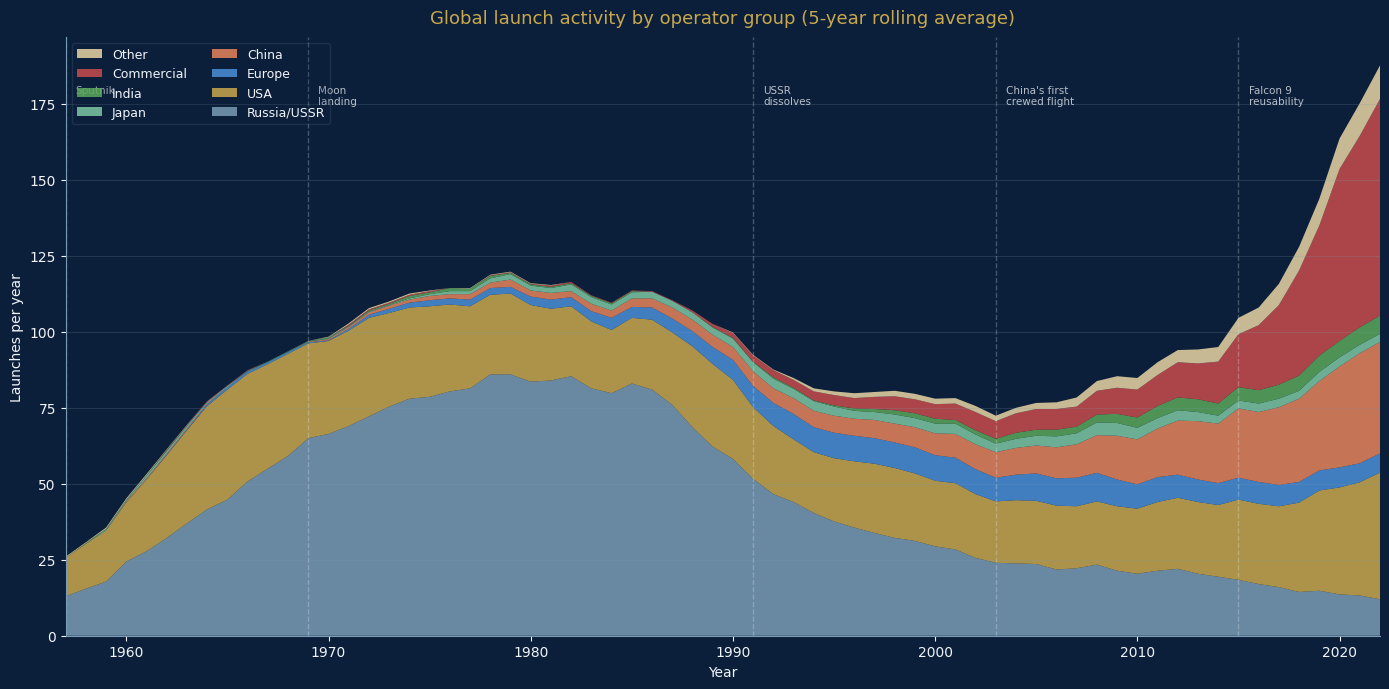

In [6]:
# ── Launch activity by operator group: stacked area ───────────────────────────

group_order = ['Russia/USSR', 'USA', 'Europe', 'China',
               'Japan', 'India', 'Commercial', 'Other']
group_colors = {
    'Russia/USSR': MUTED,
    'USA':         GOLD,
    'Europe':      BLUE,
    'China':       ORANGE,
    'Japan':       TEAL,
    'India':       GREEN,
    'Commercial':  RED,
    'Other':       LGOLD,
}

# Annual counts, smoothed
annual = (df.groupby(['Year', 'OperatorGroup'])
            .size()
            .unstack(fill_value=0))

present = [g for g in group_order if g in annual.columns]
annual  = annual.reindex(columns=present, fill_value=0)
smooth  = annual.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(NAVY)

colors = [group_colors.get(g, WHITE) for g in present]
ax.stackplot(smooth.index, smooth[present].T,
             labels=present, colors=colors, alpha=0.85)

ax.set_xlim(1957, 2022)
ax.set_ylim(0)
ax.set_title("Global launch activity by operator group (5-year rolling average)",
             fontsize=13, pad=10, color=GOLD)
ax.set_ylabel("Launches per year")
ax.set_xlabel("Year")
ax.grid(axis='y', alpha=0.2)

moments = [
    (1957, "Sputnik"),
    (1969, "Moon\nlanding"),
    (1991, "USSR\ndissolves"),
    (2003, "China's first\ncrewed flight"),
    (2015, "Falcon 9\nreusability"),
]
for yr, label in moments:
    ax.axvline(yr, color=WHITE, alpha=0.25, lw=1, linestyle='--')
    ax.text(yr + 0.5, ax.get_ylim()[1] * 0.92, label,
            color=WHITE, fontsize=7.5, va='top', alpha=0.75)

handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels_leg[::-1],
          loc='upper left', fontsize=9, framealpha=0.15, ncol=2)

plt.tight_layout()
plt.savefig('workshop7_s1_geography.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()


### Interpretation

The Russian/Soviet share peaks in the late 1970s and declines steadily from the mid-1980s onward. The 'Commercial' group is essentially absent until after 2010. These two patterns are connected.

Pick one of those two transitions and construct a single argument (grounded in political, economic, or strategic context rather than technology) that explains the shape of the curve. Section 2 will give you the economic mechanism behind the commercial surge; try to arrive at your own hypothesis first.


*Write your response here. Double-click this cell to edit.*



---
## Section 2: The Price of Admission -- What Changed, and Why Didn't It Happen Sooner?

The Space Shuttle was sold to Congress in the 1970s as a reusable vehicle that would dramatically reduce launch costs. The chart below shows how that worked out.

From 1970 to approximately 2010, the cost per kilogram to low Earth orbit was remarkably stable: between $15,000 and $55,000 regardless of which country built the rocket, and regardless of advances in materials, computing, and engineering. Then, in roughly a decade, it fell by a factor of twenty.

This wasn't purely a technology story. To understand why costs collapsed when they did -- rather than in 1990 or 1980 -- you need to look at the *business model*, not just the rocket design.


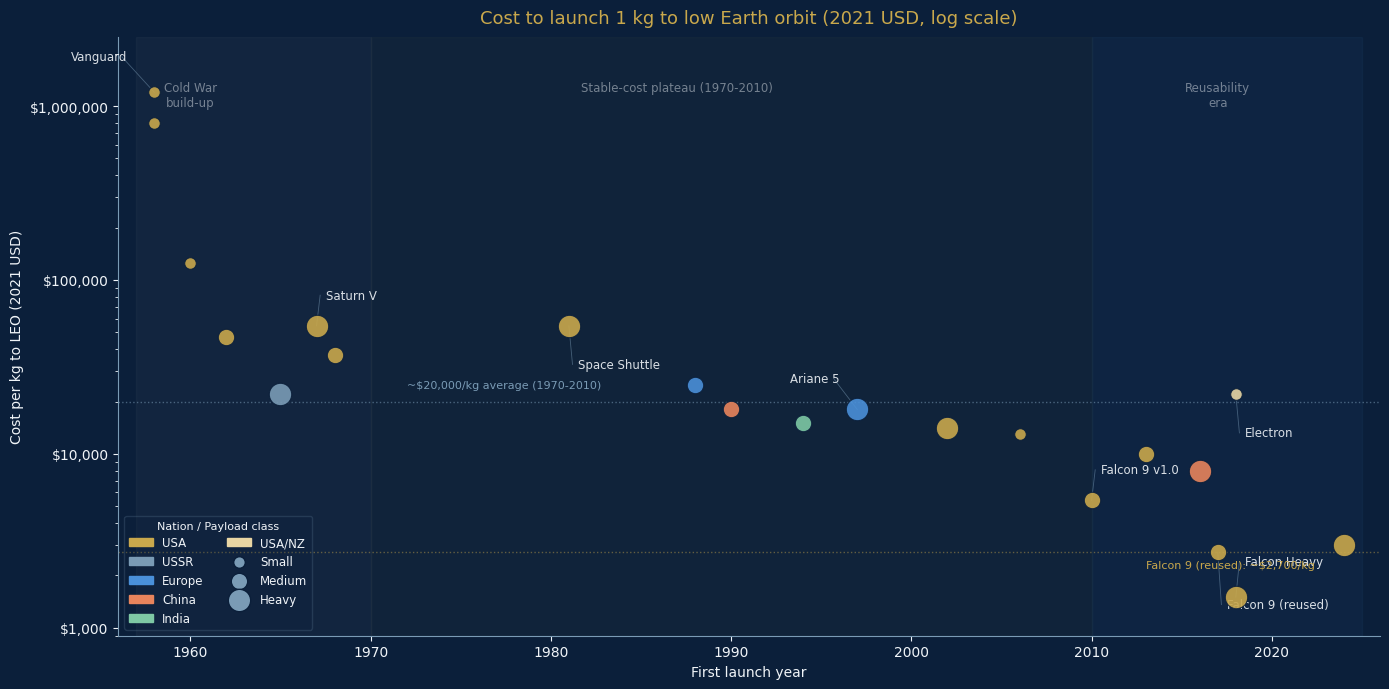

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_yscale('log')

nation_palette = {
    'USA':    GOLD,
    'USSR':   MUTED,
    'Europe': BLUE,
    'China':  ORANGE,
    'India':  TEAL,
    'USA/NZ': LGOLD,
}
class_sizes = {'Small': 70, 'Medium': 140, 'Heavy': 260}

# Era shading
ax.axvspan(1957, 1970, color=WHITE, alpha=0.03)
ax.axvspan(1970, 2010, color=GOLD,  alpha=0.03)
ax.axvspan(2010, 2025, color=BLUE,  alpha=0.05)

for era, label in [(1960, 'Cold War\nbuild-up'),
                   (1987, 'Stable-cost plateau (1970-2010)'),
                   (2017, 'Reusability\nera')]:
    ax.text(era, 1_400_000, label, color=WHITE, alpha=0.45, fontsize=8.5,
            ha='center', va='top')

lc = launch_costs.sort_values('Year')
for _, row in lc.iterrows():
    color = nation_palette.get(row['Nation'], WHITE)
    size  = class_sizes.get(row['Class'], 120)
    ax.scatter(row['Year'], row['CostPerKg'], color=color, s=size,
               zorder=5, edgecolors=NAVY, linewidth=0.8, alpha=0.9)

# Annotate key vehicles
labels_cfg = {
    'Vanguard':          (-1.5,  1.6, 'right'),
    'Saturn V':          (0.5,   1.5, 'left'),
    'Space Shuttle':     (0.5,   0.6, 'left'),
    'Falcon 9 v1.0':     (0.5,   1.5, 'left'),
    'Falcon 9 (reused)': (0.5,   0.5, 'left'),
    'Falcon Heavy':      (0.5,   1.6, 'left'),
    'Ariane 5':          (-1.0,  1.5, 'right'),
    'Electron':          (0.5,   0.6, 'left'),
}
for _, row in lc.iterrows():
    if row['Vehicle'] not in labels_cfg:
        continue
    dx, dy_mult, ha = labels_cfg[row['Vehicle']]
    x_txt = row['Year'] + dx
    y_txt = row['CostPerKg'] * dy_mult
    ax.text(x_txt, y_txt, row['Vehicle'],
            color=WHITE, fontsize=8.5, ha=ha, va='center', alpha=0.9)
    # Simple connector line
    ax.plot([row['Year'], x_txt - (0.3 if ha=='right' else 0.3)],
            [row['CostPerKg'], y_txt],
            color=MUTED, lw=0.6, alpha=0.5)

# Reference lines
ax.axhline(20_000, color=MUTED, lw=1, linestyle=':', alpha=0.55)
ax.text(1972, 24_000, '~$20,000/kg average (1970-2010)',
        color=MUTED, fontsize=8)
ax.axhline(2_720, color=GOLD, lw=1, linestyle=':', alpha=0.45)
ax.text(2013, 2_200, 'Falcon 9 (reused): ~$2,700/kg',
        color=GOLD, fontsize=8)

legend_handles = [
    mpatches.Patch(color=c, label=n) for n, c in nation_palette.items()
] + [
    plt.scatter([], [], s=sz, color=MUTED, label=cl, edgecolors=NAVY)
    for cl, sz in class_sizes.items()
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=8.5,
          framealpha=0.2, ncol=2, title='Nation / Payload class',
          title_fontsize=8)

ax.set_xlim(1956, 2026)
ax.set_ylim(900, 2_500_000)
ax.set_title("Cost to launch 1 kg to low Earth orbit (2021 USD, log scale)",
             fontsize=13, pad=10, color=GOLD)
ax.set_xlabel("First launch year")
ax.set_ylabel("Cost per kg to LEO (2021 USD)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('workshop7_s2_costs.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()


In [8]:


shuttle_per_kg   = 54_500   # 2021 USD
falcon9_per_kg   = 2_720    # 2021 USD, reused booster
falcon_heavy_per_kg = 1_500

# Scenario 1: a single science satellite (400 kg)
payload_science = 400
print("Scenario 1: One 400 kg science satellite")
print(f"  Shuttle era launch cost:  ${shuttle_per_kg * payload_science:>12,.0f}")
print(f"  Falcon 9 launch cost:     ${falcon9_per_kg * payload_science:>12,.0f}")
print(f"  Cost reduction factor:    {shuttle_per_kg / falcon9_per_kg:.1f}x")
print()

# Scenario 2: a commercial Earth observation constellation (500 small sats, 100 kg each)
n_sats     = 500
sat_mass   = 100
total_mass = n_sats * sat_mass
print(f"Scenario 2: {n_sats}-satellite EO constellation ({sat_mass} kg each)")
print(f"  Total launch mass: {total_mass:,} kg")
print(f"  Launch cost (Shuttle era): ${shuttle_per_kg * total_mass / 1e9:.1f}B")
print(f"  Launch cost (Falcon 9):    ${falcon9_per_kg * total_mass / 1e9:.2f}B")
print(f"  Launch cost (F. Heavy):    ${falcon_heavy_per_kg * total_mass / 1e9:.2f}B")
print()
print("Question: In Scenario 2, even with Falcon 9 prices, the constellation")
print("still costs hundreds of millions. What else had to get cheaper for")
print("commercial operators like Planet Labs to exist?")
print("(Hint: what is the other major cost in building a constellation?)")


Scenario 1: One 400 kg science satellite
  Shuttle era launch cost:  $  21,800,000
  Falcon 9 launch cost:     $   1,088,000
  Cost reduction factor:    20.0x

Scenario 2: 500-satellite EO constellation (100 kg each)
  Total launch mass: 50,000 kg
  Launch cost (Shuttle era): $2.7B
  Launch cost (Falcon 9):    $0.14B
  Launch cost (F. Heavy):    $0.07B

Question: In Scenario 2, even with Falcon 9 prices, the constellation
still costs hundreds of millions. What else had to get cheaper for
commercial operators like Planet Labs to exist?
(Hint: what is the other major cost in building a constellation?)


### Interpretation

The Space Shuttle was sold to Congress in the 1970s as a reusable vehicle that would dramatically cut launch costs. It didn't: it cost roughly the same per kilogram as the Saturn V it replaced. SpaceX's Falcon 9, also partially reusable, achieved a 20-fold cost reduction.

The difference is not primarily engineering. The Shuttle was procured under cost-plus government contracts, where the manufacturer is reimbursed for costs incurred regardless of outcome. SpaceX used fixed-price commercial contracts, where cost overruns come out of the company's own margin.

What does this procurement difference predict about incentives to reduce cost (before any consideration of rocket design)? And what does it suggest about why cost reduction in launch took until the 2010s rather than happening earlier?


*Write your response here. Double-click this cell to edit.*



---
## Section 3: Does More Commercial Activity Mean More Science in Space?

A reasonable intuition: launch costs dropped 20-fold, so launches became cheaper, so science missions became cheaper, so we get more science.


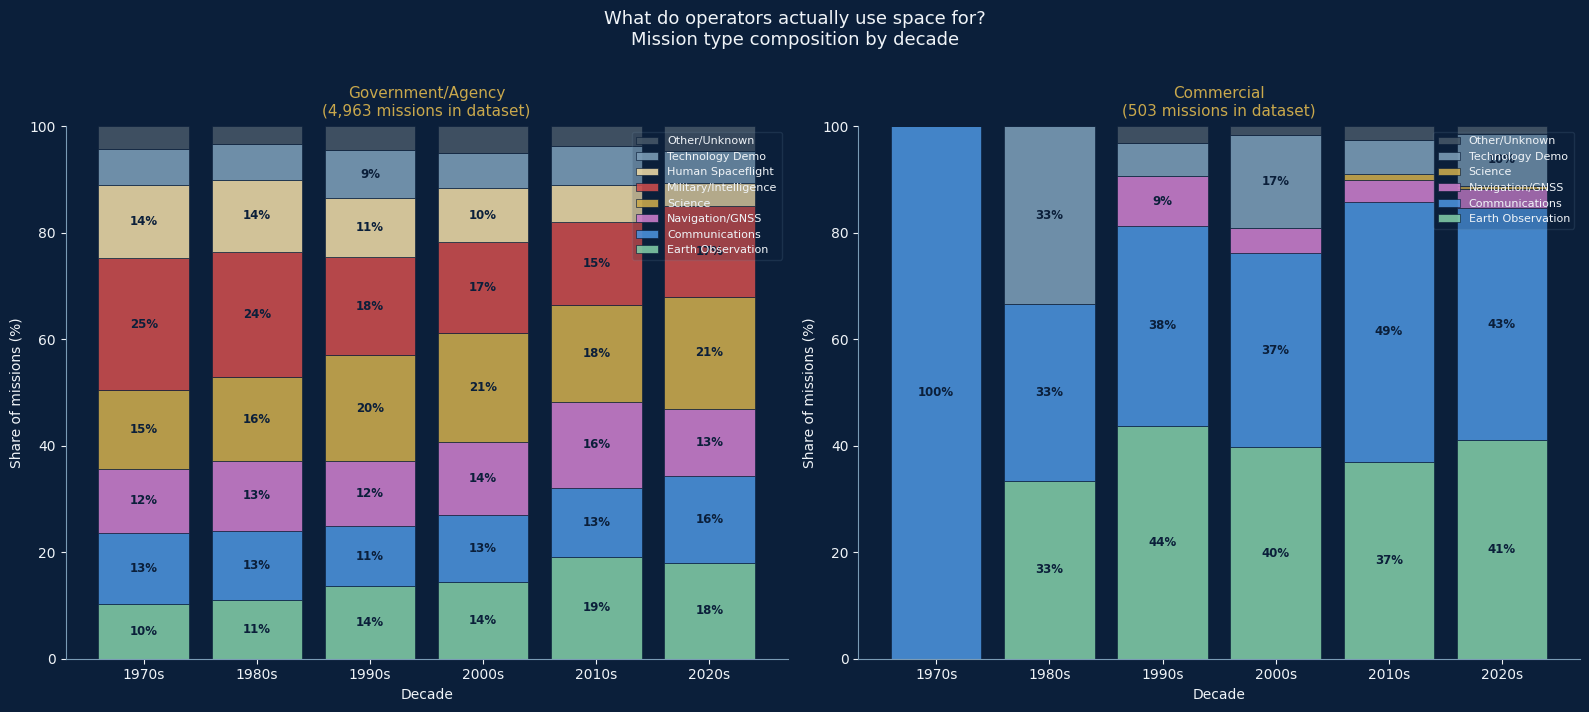

In [9]:
# Mission type composition: government vs commercial, by decade
# Shows what each category of operator actually uses space for

df['OperatorClass'] = df['OperatorGroup'].apply(
    lambda g: 'Commercial' if g == 'Commercial' else 'Government/Agency')

mission_order = ['Earth Observation', 'Communications', 'Navigation/GNSS',
                 'Science', 'Military/Intelligence', 'Human Spaceflight',
                 'Technology Demo', 'Other/Unknown']

df_d = df[df['Decade'].between(1970, 2020)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(NAVY)

for ax, op_class in zip(axes, ['Government/Agency', 'Commercial']):
    sub = df_d[df_d['OperatorClass'] == op_class]
    if len(sub) == 0:
        ax.text(0.5, 0.5, f'No data for "{op_class}"',
                ha='center', va='center', transform=ax.transAxes)
        continue

    pivot = (sub.groupby(['Decade', 'MissionType'])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=[m for m in mission_order
                                  if m in sub['MissionType'].unique()],
                        fill_value=0))
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    decades   = [f"{int(d)}s" for d in pivot_pct.index]
    bottom    = np.zeros(len(pivot_pct))

    for mtype in pivot_pct.columns:
        color = TYPE_COLORS.get(mtype, WHITE)
        vals  = pivot_pct[mtype].values
        ax.bar(decades, vals, bottom=bottom, color=color, label=mtype,
               edgecolor=NAVY, linewidth=0.5, alpha=0.9)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 9:
                ax.text(j, b + v / 2, f'{v:.0f}%',
                        ha='center', va='center', color=NAVY,
                        fontsize=8.5, fontweight='bold')
        bottom += vals

    n_missions = len(sub)
    ax.set_ylim(0, 100)
    ax.set_title(f"{op_class}\n({n_missions:,} missions in dataset)",
                 fontsize=11, color=GOLD, pad=8)
    ax.set_ylabel("Share of missions (%)")
    ax.set_xlabel("Decade")

    handles, lab = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], lab[::-1], fontsize=8,
              framealpha=0.15, loc='upper right',
              bbox_to_anchor=(1, 1))

fig.suptitle("What do operators actually use space for?\n"
             "Mission type composition by decade",
             fontsize=13, color=WHITE, y=1.01)
plt.tight_layout()
plt.savefig('workshop7_s3_missionmix.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()


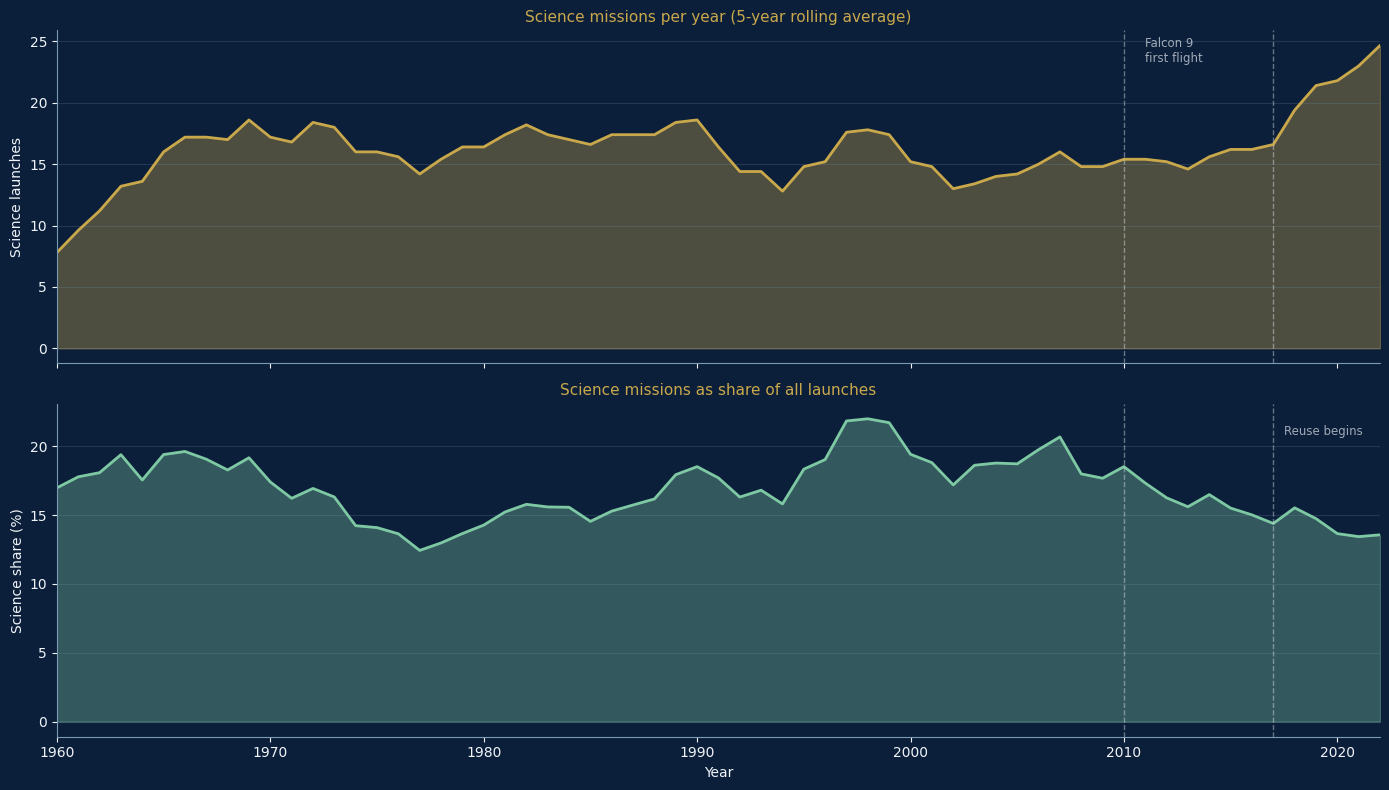

Science missions as share of all launches, by decade:
Decade
1960    18.7
1970    14.7
1980    15.7
1990    19.1
2000    18.8
2010    15.2
2020    13.1


In [10]:
# Has science mission volume grown since launch costs fell?

science_annual = (
    df[df['MissionType'] == 'Science']
    .groupby('Year').size()
    .reindex(range(df['Year'].min(), df['Year'].max() + 1), fill_value=0)
    .rolling(5, center=True, min_periods=1).mean()
)

# Also compute science as % of all launches per year
pct_science = (
    df.groupby('Year')
    .apply(lambda x: (x['MissionType'] == 'Science').sum() / len(x) * 100)
    .rolling(5, center=True, min_periods=1).mean()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor(NAVY)

# Absolute count
ax1.fill_between(science_annual.index, science_annual,
                 color=GOLD, alpha=0.35)
ax1.plot(science_annual.index, science_annual, color=GOLD, lw=2)
ax1.set_title("Science missions per year (5-year rolling average)",
              fontsize=11, color=GOLD, pad=6)
ax1.set_ylabel("Science launches")

# % of all launches
ax2.fill_between(pct_science.index, pct_science,
                 color=TEAL, alpha=0.35)
ax2.plot(pct_science.index, pct_science, color=TEAL, lw=2)
ax2.set_title("Science missions as share of all launches",
              fontsize=11, color=GOLD, pad=6)
ax2.set_ylabel("Science share (%)")
ax2.set_xlabel("Year")

# Mark Falcon 9 reuse era
for ax in (ax1, ax2):
    ax.axvline(2010, color=WHITE, lw=1, linestyle='--', alpha=0.4)
    ax.axvline(2017, color=WHITE, lw=1, linestyle='--', alpha=0.4)
    ax.set_xlim(1960, 2022)
    ax.grid(axis='y', alpha=0.2)

ax1.text(2011, ax1.get_ylim()[1] * 0.9, 'Falcon 9\nfirst flight',
         color=WHITE, fontsize=8.5, alpha=0.65)
ax2.text(2017.5, ax2.get_ylim()[1] * 0.9, 'Reuse begins',
         color=WHITE, fontsize=8.5, alpha=0.65)

plt.tight_layout()
plt.savefig('workshop7_s3_science_trend.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()

# Summary table
print("Science missions as share of all launches, by decade:")
decade_sci = (df.groupby('Decade')
                .apply(lambda x: round(
                    (x['MissionType']=='Science').sum() / len(x) * 100, 1))
                .rename('Sci %'))
print(decade_sci[decade_sci.index >= 1960].to_string())


### Interpretation

Commercial operators concentrate almost entirely in Earth Observation and Communications. The absolute number of science missions has not grown significantly since launch costs fell. For a typical planetary science mission, the launch vehicle accounts for only 10-20% of total cost -- most of the money is in the instrument and spacecraft.

Taken together, these patterns suggest that cheaper launches were never going to produce more science on their own, because launch cost was never the binding constraint.

Who pays for science data, and who pays for EO or communications data? Follow that distinction to its logical conclusion: what does it predict about the long-term balance between publicly funded science and commercially funded applications in orbit?


*Write your response here. Double-click this cell to edit.*



---
## Section 4: The Architecture of Funding -- Who Actually Pays for Space?

Space Foundation reported the global space economy at $613 billion in 2024, with the commercial sector accounting for 78% and government spending the remaining 22%.

This section examines what that government 22% actually contains -- and argues that the standard headline significantly understates the role of public investment in making the industry possible in the first place.

Two agencies are almost entirely absent from popular accounts of the space industry. They are almost certainly the largest single influence on its development.


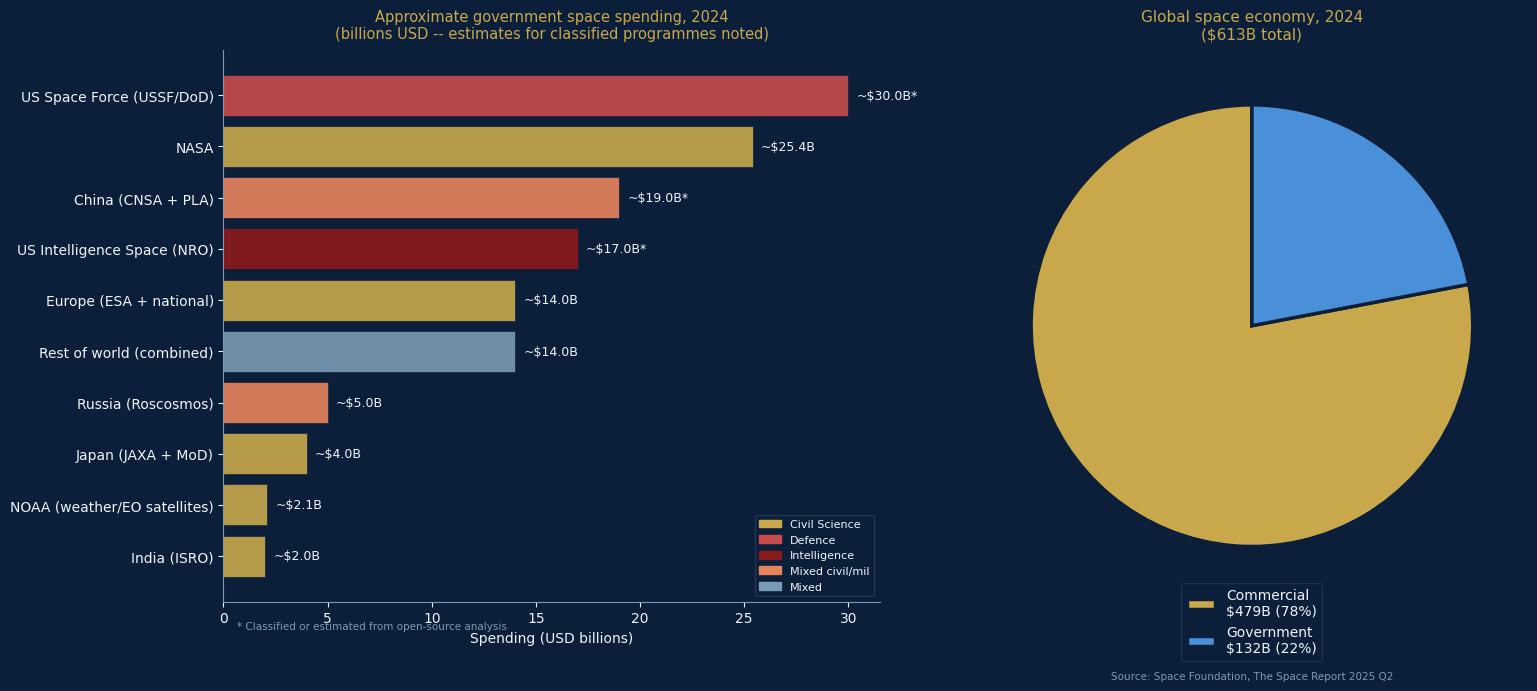

In [11]:
# ── Approximate government space spending breakdown, 2024 ─────────────────────
# Sources: Space Foundation (2025), CSIS, public budget filings, estimates
# Note: classified budgets (NRO, China PLA) are estimated from open-source analysis

gov_data = pd.DataFrame([
    {'Category': 'NASA',                         'Spend_B': 25.4,
     'Type': 'Civil Science',   'Transparency': 'Public'},
    {'Category': 'NOAA (weather/EO satellites)', 'Spend_B': 2.1,
     'Type': 'Civil Science',   'Transparency': 'Public'},
    {'Category': 'US Space Force (USSF/DoD)',    'Spend_B': 30,
     'Type': 'Defence',         'Transparency': 'Partially classified'},
    {'Category': 'US Intelligence Space (NRO)',  'Spend_B': 17,
     'Type': 'Intelligence',    'Transparency': 'Classified (estimated)'},
    {'Category': 'China (CNSA + PLA)',           'Spend_B': 19,
     'Type': 'Mixed civil/mil', 'Transparency': 'Estimated'},
    {'Category': 'Europe (ESA + national)',      'Spend_B': 14,
     'Type': 'Civil Science',   'Transparency': 'Public'},
    {'Category': 'Russia (Roscosmos)',           'Spend_B': 5,
     'Type': 'Mixed civil/mil', 'Transparency': 'Partially public'},
    {'Category': 'Japan (JAXA + MoD)',           'Spend_B': 4,
     'Type': 'Civil Science',   'Transparency': 'Public'},
    {'Category': 'India (ISRO)',                 'Spend_B': 2,
     'Type': 'Civil Science',   'Transparency': 'Public'},
    {'Category': 'Rest of world (combined)',     'Spend_B': 14,
     'Type': 'Mixed',           'Transparency': 'Partial'},
])

type_bar_colors = {
    'Civil Science':   GOLD,
    'Defence':         RED,
    'Intelligence':    "#8B1A1A",
    'Mixed civil/mil': ORANGE,
    'Mixed':           MUTED,
}
gov_data['Color'] = gov_data['Type'].map(type_bar_colors)
gov_data = gov_data.sort_values('Spend_B', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(NAVY)

# Left: horizontal bar breakdown of government spending
bars = ax1.barh(gov_data['Category'], gov_data['Spend_B'],
                color=gov_data['Color'], edgecolor=NAVY, linewidth=0.5,
                alpha=0.9)
ax1.set_title("Approximate government space spending, 2024\n"
              "(billions USD -- estimates for classified programmes noted)",
              fontsize=10.5, color=GOLD, pad=8)
ax1.set_xlabel("Spending (USD billions)")

for bar, (_, row) in zip(bars, gov_data.iterrows()):
    label = f"~${row.Spend_B}B"
    if 'stimate' in row.Transparency or 'lassif' in row.Transparency:
        label += "*"
    ax1.text(row.Spend_B + 0.4,
             bar.get_y() + bar.get_height() / 2,
             label, va='center', color=WHITE, fontsize=9)

ax1.text(0.02, -0.05,
         "* Classified or estimated from open-source analysis",
         transform=ax1.transAxes, color=MUTED, fontsize=7.5)

legend_patches = [mpatches.Patch(color=c, label=t)
                  for t, c in type_bar_colors.items()]
ax1.legend(handles=legend_patches, loc='lower right', fontsize=8,
           framealpha=0.2)

# Right: global economy pie
ax2.set_facecolor(NAVY)
sizes  = [78, 22]
labels = ['Commercial\n$479B (78%)', 'Government\n$132B (22%)']
colors_pie = [GOLD, BLUE]
wedges, texts = ax2.pie(
    sizes, colors=colors_pie, startangle=90,
    wedgeprops={'edgecolor': NAVY, 'linewidth': 2.5},
)
ax2.legend(wedges, labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.12), fontsize=10,
           framealpha=0.15)
ax2.set_title("Global space economy, 2024\n($613B total)",
              fontsize=11, color=GOLD, pad=8)
ax2.text(0, -1.6,
         "Source: Space Foundation, The Space Report 2025 Q2",
         ha='center', color=MUTED, fontsize=7.5)

plt.tight_layout()
plt.savefig('workshop7_s4_funding.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()


### A question of visibility

Look at the bar chart again with fresh eyes.

NASA's budget is &dollar;25.4 billion. The Space Force's budget is &dollar;30 billion. The NRO's estimated budget is &dollar;17 billion. NASA is probably the most recognised acronym in global science. Most people could not name a single USSF programme. Almost nobody outside the intelligence community had heard of the NRO before its declassification in 1992.

This gap between budget size and public visibility is not accidental. It reflects fundamentally different mandates: NASA publishes everything, holds press conferences, names its rovers, and livestreams its launches because its political justification depends on public support. The USSF and NRO exist to provide capability to warfighters and analysts, not to inspire schoolchildren -- so they operate quietly, often under classification, and their contributions to the broader space ecosystem are structurally invisible in most accounts of the industry.

NOAA is a useful comparison in the other direction. Its weather and environmental satellites are the infrastructure that underpins every weather forecast in the western hemisphere, yet it is rarely mentioned in the same breath as NASA despite operating some of the most consequential Earth observation assets in orbit. NOAA's budget is modest (~&dollar;2 billion for space) precisely because its satellites are utilitarian rather than exploratory.

The implication: when we talk about the "space industry," we are usually talking about its most visible slice. The chart above shows what the full picture looks like when you include the parts that don't hold press conferences.

### The agencies most accounts omit

**The National Reconnaissance Office (NRO)**

Established in 1961, classified until 1992, the NRO operates the United States fleet of reconnaissance satellites. Its annual budget -- approximately &dollar;15-18 billion, largely classified -- is comparable to NASA's entire budget. Its role in shaping the commercial industry is not widely acknowledged but is substantial:

The NRO's CORONA programme (1959-1972) demonstrated that high-resolution Earth imaging from orbit was technically feasible. When CORONA imagery was declassified in 1995, it immediately became the technical baseline from which commercial Earth observation companies could understand what was achievable. The NRO proved the concept; commercial operators built cheaper versions.

Today, the NRO is one of the largest customers for commercial EO imagery, purchasing data from Planet Labs, Maxar, and others. Commercial operators did not simply emerge from nowhere -- they found their first guaranteed market partly because the US government needed to supplement classified systems with cheaper commercial data.

**The US Space Force (USSF)**

Established in 2019, the USSF manages military space operations with a budget of approximately &dollar;30 billion. Its procurement decisions have been defining for the launch market:

The National Security Space Launch (NSSL) programme -- which contracts commercial launch vehicles to carry military payloads -- was the mechanism by which SpaceX was certified as a credible heavy-lift provider for government payloads. United Launch Alliance (ULA) held a monopoly on US military launches for a decade before NSSL opened competition. The government's willingness to fly military payloads on SpaceX rockets was a commercial validation that no private satellite operator alone could have provided.

The broader implication: the "78% commercial" space economy did not develop despite government -- it developed because governments absorbed technical risk, provided anchor customers, and funded the infrastructure that commercial operators then exploited.


In [12]:
# ── The GPS return-on-investment case ────────────────────────────────────────
# GPS is the clearest example of a space investment whose returns are
# enormous, diffuse, and captured almost entirely outside the agency that built it

print("GPS: Public investment and economic return")
print("=" * 60)
print()

gps = {
    'Programme start':                          1973,
    'Initial operating capability':             1993,
    'Total US government investment (nominal)': "$12B (approx., 1973-2000)",
    'Number of GPS satellites':                 31,
    'Annual US economic benefit (2019 est.)':   "$321B",
    'Source of benefit estimate':               "RTI International / US DoT (2019)",
    'Sectors directly dependent on GPS (CISA)': 16,
    'Implied annual ROI on original investment': "~27x per year",
}

for k, v in gps.items():
    print(f"  {k:<44} {v}")

print()
print("Where does the $321B go?")
print("  - Precision agriculture (timing, field mapping):       ~$8B/year")
print("  - Aviation navigation and efficiency:                  ~$40B/year")
print("  - Financial transactions (timestamping):              ~$109B/year")
print("  - Logistics and supply chain:                          ~$70B/year")
print("  - Emergency services, surveying, telecom sync:         ~$94B/year")
print()
print("The US Department of Defense built GPS.")
print("Airlines, banks, and farmers capture a lot of the return.")


GPS: Public investment and economic return

  Programme start                              1973
  Initial operating capability                 1993
  Total US government investment (nominal)     $12B (approx., 1973-2000)
  Number of GPS satellites                     31
  Annual US economic benefit (2019 est.)       $321B
  Source of benefit estimate                   RTI International / US DoT (2019)
  Sectors directly dependent on GPS (CISA)     16
  Implied annual ROI on original investment    ~27x per year

Where does the $321B go?
  - Precision agriculture (timing, field mapping):       ~$8B/year
  - Aviation navigation and efficiency:                  ~$40B/year
  - Financial transactions (timestamping):              ~$109B/year
  - Logistics and supply chain:                          ~$70B/year
  - Emergency services, surveying, telecom sync:         ~$94B/year

The US Department of Defense built GPS.
Airlines, banks, and farmers capture a lot of the return.


### Interpretation

1. Add up the US civil + USSF + NRO figures from the bar chart. How does that total compare to the combined spending of Europe, Japan, India, and Russia combined? What does this concentration suggest about claims that space has become a "global industry"?

2. The NRO proved satellite Earth imaging was feasible; became an anchor customer for commercial equivalents; and commercial operators built a market on that foundation. The risk was absorbed by government; the ongoing profits flow to private companies. Is this the expected pattern for publicly funded frontier infrastructure, or a problem? Can you think of another industry where the same dynamic played out?

3. GPS costs &dollar;12B to build over 27 years and returns an estimated &dollar;321B per year to the US economy. But the DoD does not collect this return. If you were advising a government considering a large space infrastructure investment, how would the GPS precedent inform your argument for or against making the investment?

*Your response:*


*Write your response here. Double-click this cell to edit.*

1.

2.

3.


---
## Section 5: Agency Fingerprints: Mission Mix as National Policy

Every space agency's portfolio is, in some sense, a political document. The mix of missions an agency funds reflects what its government values: scientific prestige, strategic sovereignty, economic development, or international influence.

This section generates "fingerprints" for major agencies -- normalised profiles of what they actually launch -- and asks you to read them as policy statements rather than just technical catalogues.


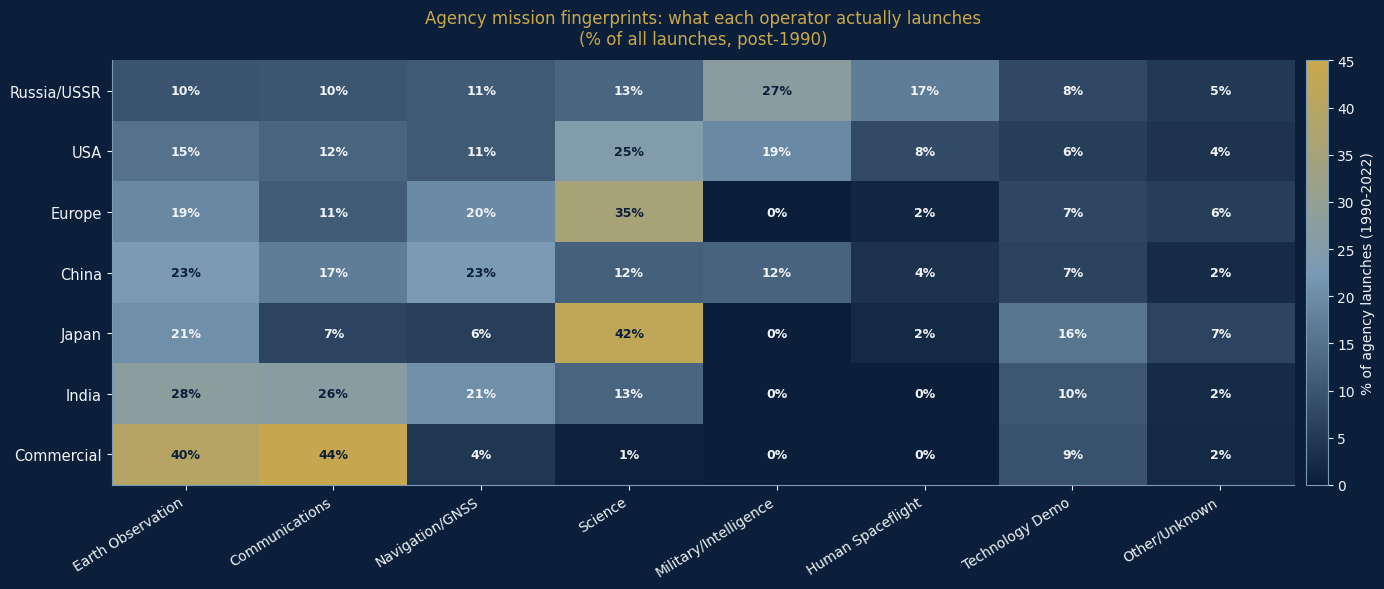

In [13]:
# ── Agency mission fingerprint heatmap ──────────────────────────────────────

agency_order = ['Russia/USSR', 'USA', 'Europe', 'China',
                'Japan', 'India', 'Commercial']
mission_order_h = ['Earth Observation', 'Communications', 'Navigation/GNSS',
                   'Science', 'Military/Intelligence', 'Human Spaceflight',
                   'Technology Demo', 'Other/Unknown']

# Focus on post-1990 for contemporary relevance
df_recent = df[(df['Year'] >= 1990) &
               (df['OperatorGroup'].isin(agency_order))].copy()

pivot = (df_recent
         .groupby(['OperatorGroup', 'MissionType'])
         .size()
         .unstack(fill_value=0)
         .reindex(index=agency_order,
                  columns=[m for m in mission_order_h
                            if m in df_recent['MissionType'].unique()],
                  fill_value=0))

pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
cmap = LinearSegmentedColormap.from_list('navygold', [NAVY, MUTED, GOLD], N=256)
im = ax.imshow(pivot_norm.values, cmap=cmap, aspect='auto', vmin=0, vmax=45)

ax.set_xticks(range(len(pivot_norm.columns)))
ax.set_xticklabels(pivot_norm.columns, rotation=32, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot_norm.index)))
ax.set_yticklabels(pivot_norm.index, fontsize=10.5)

for i in range(len(pivot_norm.index)):
    for j in range(len(pivot_norm.columns)):
        val = pivot_norm.values[i, j]
        text_color = NAVY if val > 22 else WHITE
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                color=text_color, fontsize=9, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.025)
cbar.set_label('% of agency launches (1990-2022)', color=WHITE)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=WHITE)

ax.set_title("Agency mission fingerprints: what each operator actually launches\n"
             "(% of all launches, post-1990)",
             fontsize=12, color=GOLD, pad=12)
plt.tight_layout()
plt.savefig('workshop7_s5_fingerprints.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()


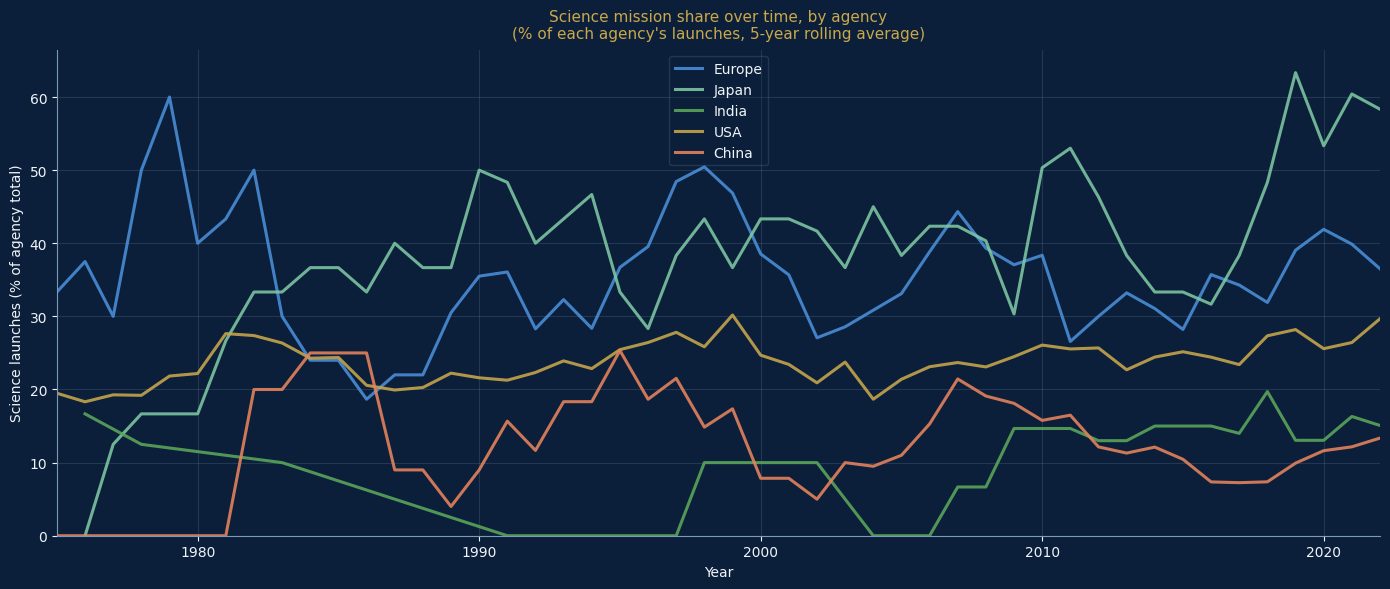

In [14]:
# ── Science investment trajectory by agency (1975-2022) ──────────────────────
# Shows how the science share has changed over time for each major agency

agencies_to_plot = [a for a in ['Europe', 'Japan', 'India', 'USA', 'China']
                    if a in df['OperatorGroup'].unique()]
agency_colors = {
    'Europe': BLUE, 'Japan': TEAL, 'India': GREEN,
    'USA': GOLD,  'China': ORANGE,
}

fig, ax = plt.subplots(figsize=(14, 6))

for agency in agencies_to_plot:
    sub = df[(df['OperatorGroup'] == agency) & (df['Year'] >= 1975)]
    if len(sub) < 10:
        continue
    sci_share = (sub.groupby('Year')
                    .apply(lambda x: (x['MissionType'] == 'Science').sum()
                                     / len(x) * 100)
                    .rolling(5, center=True, min_periods=1).mean())
    ax.plot(sci_share.index, sci_share,
            color=agency_colors.get(agency, WHITE),
            lw=2.2, label=agency, alpha=0.88)

ax.set_title("Science mission share over time, by agency\n"
             "(% of each agency's launches, 5-year rolling average)",
             fontsize=11, color=GOLD, pad=8)
ax.set_xlabel("Year")
ax.set_ylabel("Science launches (% of agency total)")
ax.set_xlim(1975, 2022)
ax.set_ylim(0)
ax.legend(fontsize=10, framealpha=0.2)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('workshop7_s5_sci_trend.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()


### Interpretation

1. ISRO (India) shows a high proportion of Earth Observation and Communications relative to Science. One reading: India has a "less ambitious" program. Offer a different reading -- one that situates ISRO's mission mix within India's development agenda. What would a satellite-based agricultural monitoring system or remote sensing capacity mean for a country of 1.4 billion people, most of whom depend on rain-fed farming?

2. ESA's science-heavy profile is striking, especially relative to other agencies of comparable size. ESA is not a national agency -- it is a consortium of 22 member states, each with a veto over major decisions. How might this governance structure help explain why ESA's portfolio looks the way it does? What kinds of missions are easiest to justify to a multi-national committee that needs scientific legitimacy rather than national prestige?

3. Looking at the science share trend over time: pick one agency whose trajectory surprises you and construct a hypothesis about what drove the change. Your hypothesis should connect the data pattern to something in the political or economic history of that country's space program.

*Your response:*


*Write your response here. Double-click this cell to edit.*

1.

2.

3.


---
## Section 6: Comparative Agency Analysis
DO THIS IF TIME PERMITS

---

Using the data and analysis from Sections 1 to 5, write a comparative analysis of **two space agencies** of your choice.

Your analysis should address the following in **200-250 words**:

- What does each agency's mission mix suggest about its institutional mandate and the national priorities it serves?
- How does each agency's approach reflect its funding model -- and who ultimately pays and who benefits?
- What types of returns (scientific, economic, strategic, or social) might each agency's strategy generate, and where do those returns flow?
- Based on the trends you have observed, how might each agency's role in the global space economy shift over the next decade?

**Assessment criteria:**
- Your analysis must reference specific features of the data you have explored, not general knowledge alone.
- You should demonstrate awareness of the economic and political context that shapes each agency's choices.
- You will be assessed on the quality of your reasoning.

**Available agency labels** (use these exact names):
`USA`, `Russia/USSR`, `Europe`, `China`, `Japan`, `India`, `Commercial`

---

The code cell below generates a side-by-side mission profile for your two chosen agencies.  
Fill in `AGENCY_A` and `AGENCY_B` and run it before writing your response.


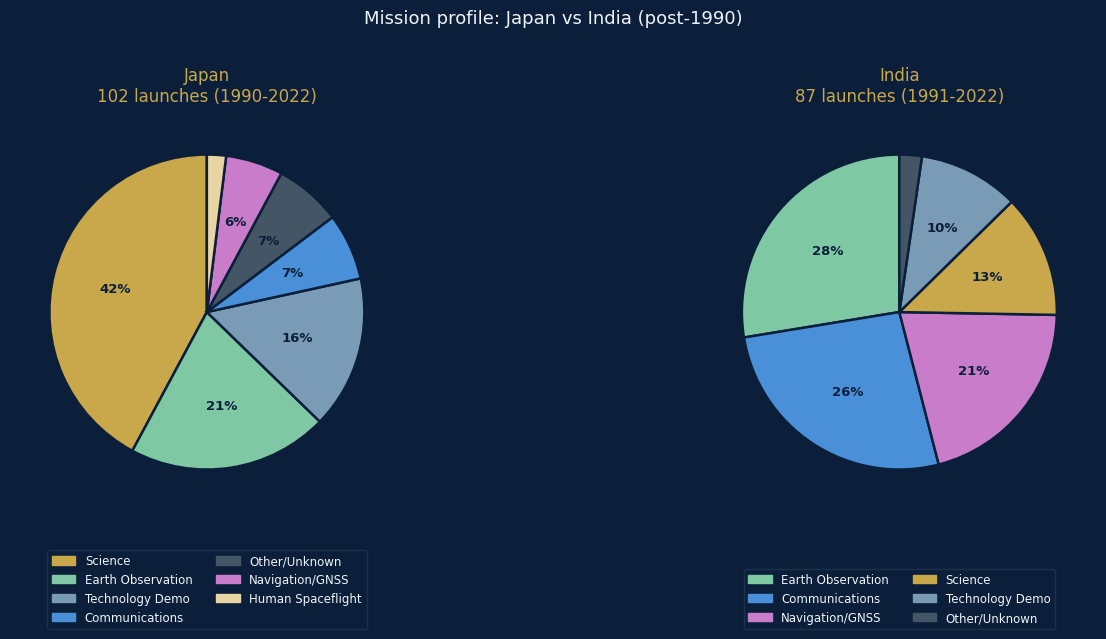


Japan -- top mission types (post-1990):
MissionType
Science              42.2
Earth Observation    20.6
Technology Demo      15.7
Communications        6.9
Other/Unknown         6.9
Navigation/GNSS       5.9
Human Spaceflight     2.0

India -- top mission types (post-1990):
MissionType
Earth Observation    27.6
Communications       26.4
Navigation/GNSS      20.7
Science              12.6
Technology Demo      10.3
Other/Unknown         2.3


In [15]:
# ── Generate comparison profile for your two agencies ────────────────────────

AGENCY_A = "Japan"    # CHANGE THIS
AGENCY_B = "India"    # CHANGE THIS

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.patch.set_facecolor(NAVY)

for ax, agency in zip(axes, [AGENCY_A, AGENCY_B]):
    sub = df_recent[df_recent['OperatorGroup'] == agency]

    if len(sub) == 0:
        ax.text(0.5, 0.5,
                f'No data for "{agency}".\nCheck spelling and capitalisation.',
                ha='center', va='center', transform=ax.transAxes,
                color=RED, fontsize=11)
        ax.set_facecolor(NAVY)
        continue

    counts     = sub['MissionType'].value_counts()
    counts_pct = counts / counts.sum() * 100
    colors     = [TYPE_COLORS.get(mt, MUTED) for mt in counts_pct.index]

    wedges, _, autotexts = ax.pie(
        counts_pct.values,
        labels=None,
        colors=colors,
        autopct=lambda p: f'{p:.0f}%' if p > 5 else '',
        startangle=90,
        wedgeprops={'edgecolor': NAVY, 'linewidth': 1.8},
    )
    for at in autotexts:
        at.set_color(NAVY)
        at.set_fontsize(9.5)
        at.set_fontweight('bold')

    yr_range = f"{int(sub['Year'].min())}-{int(sub['Year'].max())}"
    ax.set_title(f"{agency}\n{len(sub):,} launches ({yr_range})",
                 fontsize=12, color=GOLD, pad=10)

    patches = [mpatches.Patch(color=c, label=l)
               for c, l in zip(colors, counts_pct.index)]
    ax.legend(handles=patches, loc='lower center',
              bbox_to_anchor=(0.5, -0.32), fontsize=8.5,
              framealpha=0.15, ncol=2)

fig.suptitle(f"Mission profile: {AGENCY_A} vs {AGENCY_B} (post-1990)",
             fontsize=13, color=WHITE, y=1.02)
plt.tight_layout()
plt.savefig('workshop7_s6_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()

# Print summary statistics to inform your writing
for agency in [AGENCY_A, AGENCY_B]:
    sub = df_recent[df_recent['OperatorGroup'] == agency]
    if len(sub) == 0:
        continue
    print(f"\n{agency} -- top mission types (post-1990):")
    top = (sub['MissionType'].value_counts(normalize=True) * 100).round(1)
    print(top.to_string())


### Your comparative analysis



**Agency A:**

**Agency B:**

*Double-click this cell to write your response.*

